---
tags: [integration, optimization, variational]
---

# QURI Partsサポート

このページでは、具体的な最適化問題を通して、Qamomileの[QURI Parts](https://quri-parts.qunasys.com/)バックエンドを紹介します。
このチュートリアルでは、小さなMaxCutインスタンスに対するQAOA最適化を例に、Qamomileの量子カーネルをQURI Parts回路へトランスパイルし、サンプリングと期待値評価を行います。
`QuriPartsExecutor`は、デフォルトで高速なC++製状態ベクトルシミュレータ[Qulacs](https://docs.qulacs.org/)を使うため、以下の例は追加設定なしでローカルCPU上で実行できます。

In [1]:
# 最新のQamomileをQURI Parts用の追加依存と一緒にpipからインストールします。
# !pip install "qamomile[quri_parts]"

In [2]:
# このチュートリアルで使うライブラリをここにまとめます。
import os

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from quri_parts.circuit.noise import (  # type: ignore[import-not-found]
    DepolarizingNoise,
    NoiseModel,
)
from quri_parts.circuit.utils.circuit_drawer import (  # type: ignore[import-not-found]
    draw_circuit,
)
from quri_parts.qulacs.sampler import (  # type: ignore[import-not-found]
    create_qulacs_noisesimulator_sampler,
)
from scipy.optimize import minimize

import qamomile.circuit as qmc
import qamomile.observable as qm_o
from qamomile.optimization.binary_model import BinaryModel
from qamomile.quri_parts import QuriPartsExecutor, QuriPartsTranspiler
from qamomile.quri_parts.observable import hamiltonian_to_quri_operator

## MaxCut問題

QURI Parts連携の説明に集中するため、[MaxCutに対するQAOAチュートリアル](../algorithm/qaoa_maxcut.ipynb)と同じ5ノードの小さなグラフを使います。
$\sum_{(i,j) \in E}(1 - s_i s_j)/2$の最大化は、定数項を除けば、反強磁性Isingハミルトニアン$H_C = \sum_{(i,j) \in E} s_i s_j$の最小化に対応します。
重みなしMaxCutでは、すべての$J_{ij} = 1$、$h_i = 0$なので、これらの係数をそのまま`BinaryModel.from_ising`に渡します。
ここで作るモデルは、QAOAの量子カーネルに渡す`quad` / `linear`辞書と、測定結果をスピン値$(+1 / -1)$に戻すために使います。

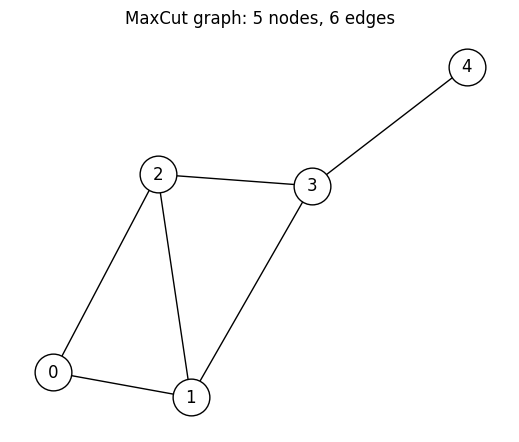

In [3]:
# MaxCutグラフを作り、Ising形式のBinaryModelへ変換します。
G = nx.Graph()
G.add_edges_from([(0, 1), (0, 2), (1, 2), (1, 3), (2, 3), (3, 4)])
num_nodes = G.number_of_nodes()

ising_quad: dict[tuple[int, int], float] = {
    tuple(sorted((i, j))): 1.0 for i, j in G.edges()
}
ising_linear: dict[int, float] = {}
spin_model = BinaryModel.from_ising(linear=ising_linear, quad=ising_quad)
# 問題の構造はグラフから一意に決まります。重みなしMaxCutでは、quad項は辺と
# 1対1に対応し、linear項は存在しません。
assert len(spin_model.quad) == G.number_of_edges()
assert len(spin_model.linear) == 0

pos = nx.spring_layout(G, seed=42)
plt.figure(figsize=(5, 4))
nx.draw(
    G,
    pos,
    with_labels=True,
    node_color="white",
    node_size=700,
    edgecolors="black",
)
plt.title(f"MaxCut graph: {num_nodes} nodes, {G.number_of_edges()} edges")
plt.show()

## `@qkernel`によるQAOAアンザッツの構築

QAOAアンザッツを小さな`@qkernel`として直接書きます。
レシピは[MaxCutに対するQAOAチュートリアル](../algorithm/qaoa_maxcut.ipynb)と同じです。計算基底の一様な重ね合わせ状態を準備した後、コスト層とミキサー層を$p$回交互に適用し、最後に計算基底で測定します。

:::{tip}
Qamomileの回転ゲートは$e^{-i\theta/2}$という規約に従います。
そのため、$1/2$係数の扱いはコスト層とミキサー層で少し異なります。
ミキサー層では`rx`に$2\beta$を渡すので、$1/2$が打ち消され、教科書通りの$e^{-i\beta X}$になります。
一方、コスト層では`rzz`に$J_{ij} \cdot \gamma$を渡すため、$1/2$は残ります。
この係数の違いは変分パラメータ$\gamma$に吸収しています。つまり、ここで使う$\gamma$は教科書のQAOAの$\gamma$の2倍に相当します。
:::

In [4]:
# QAOAを構成する再利用可能な量子カーネルを定義します。
@qmc.qkernel
def superposition(n: qmc.UInt) -> qmc.Vector[qmc.Qubit]:
    q = qmc.qubit_array(n, name="q")
    for i in qmc.range(n):
        q[i] = qmc.h(q[i])
    return q


@qmc.qkernel
def cost_layer(
    quad: qmc.Dict[qmc.Tuple[qmc.UInt, qmc.UInt], qmc.Float],
    linear: qmc.Dict[qmc.UInt, qmc.Float],
    q: qmc.Vector[qmc.Qubit],
    gamma: qmc.Float,
) -> qmc.Vector[qmc.Qubit]:
    for (i, j), Jij in quad.items():
        q[i], q[j] = qmc.rzz(q[i], q[j], angle=Jij * gamma)
    for i, hi in linear.items():
        q[i] = qmc.rz(q[i], angle=hi * gamma)
    return q


@qmc.qkernel
def mixer_layer(
    q: qmc.Vector[qmc.Qubit],
    beta: qmc.Float,
) -> qmc.Vector[qmc.Qubit]:
    n = q.shape[0]
    for i in qmc.range(n):
        q[i] = qmc.rx(q[i], angle=2.0 * beta)
    return q


@qmc.qkernel
def qaoa_ansatz(
    p: qmc.UInt,
    quad: qmc.Dict[qmc.Tuple[qmc.UInt, qmc.UInt], qmc.Float],
    linear: qmc.Dict[qmc.UInt, qmc.Float],
    n: qmc.UInt,
    gammas: qmc.Vector[qmc.Float],
    betas: qmc.Vector[qmc.Float],
) -> qmc.Vector[qmc.Bit]:
    q = superposition(n)
    for layer in qmc.range(p):
        q = cost_layer(quad, linear, q, gammas[layer])
        q = mixer_layer(q, betas[layer])
    return qmc.measure(q)

`qaoa_ansatz.draw(...)`でQamomileの回路図を描画できます。
問題の構造を決める引数(`p`、`quad`、`linear`、`n`)には具体値を渡し、層の形が見えるようにします。
一方、`gammas` / `betas`には値を渡さず、後で決めるパラメータとして残します。

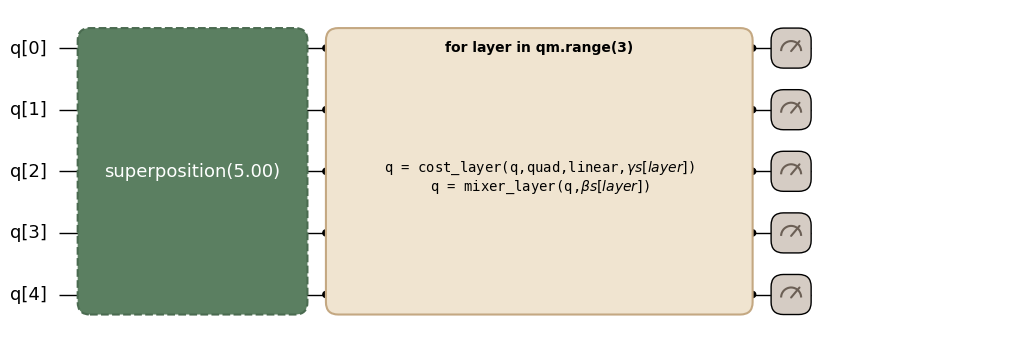

In [5]:
p = 3  # QAOAの層数
qaoa_ansatz.draw(
    p=p,
    quad=spin_model.quad,
    linear=spin_model.linear,
    n=num_nodes,
)

## QURI Partsへのトランスパイル

`QuriPartsTranspiler`は、他のバックエンドと同じように`transpile()`で使えます。
問題の構造を決める引数は`bindings`で固定し、`gammas` / `betas`はランタイムパラメータとして残します。

In [6]:
# seed付きのQURI Parts Executorを作り、アンザッツを1回だけトランスパイルします。
transpiler = QuriPartsTranspiler()

# `seed`を渡すとQulacs samplerが再現可能になります。同じseedと回路で`sample(...)`を2回呼ぶと、まったく同じショットカウントが得られます。
# 非決定的なサンプリングにしたい場合は、この引数を省略する、または`seed=None`を渡してください。
executor = QuriPartsExecutor(seed=42)

executable = transpiler.transpile(
    qaoa_ansatz,
    bindings={
        "p": p,
        "quad": spin_model.quad,
        "linear": spin_model.linear,
        "n": num_nodes,
    },
    parameters=["gammas", "betas"],
)

`executable.get_first_circuit()`で内部のQURI Parts回路を取り出せます。
取り出した回路はQURI Partsの`LinearMappedParametricQuantumCircuit`であり、$2p$個のQAOA角度(`gammas[0..p-1]`、`betas[0..p-1]`)が名前付きランタイムパラメータとして残っています。
`type(...)`とパラメータ数で確認し、さらにQURI Partsの`draw_circuit`で回路図を描画してみましょう。

In [7]:
# 出力されたQURI Parts回路を確認し、量子ビット数とパラメータ数を検証します。
quri_circuit = executable.get_first_circuit()
assert quri_circuit is not None

# `qubit_count`と`parameter_count`は問題設定から一意に決まります。
# 量子ビット数はグラフのノード数と一致し、ランタイムパラメータ数は層ごとに
# (gamma | beta)の組が1つずつ、合計2pになります。
assert quri_circuit.qubit_count == num_nodes
assert quri_circuit.parameter_count == 2 * p
print(type(quri_circuit).__name__)
print("qubit_count    :", quri_circuit.qubit_count)
print("parameter_count:", quri_circuit.parameter_count)

draw_circuit(quri_circuit, line_length=200)

LinearMappedParametricQuantumCircuit
qubit_count    : 5
parameter_count: 6
   ___     ___     ___     ___                     ___     ___     ___                     ___     ___     ___                                  
  | H |   |PPR|   |PPR|   |PRX|                   |PPR|   |PPR|   |PRX|                   |PPR|   |PPR|   |PRX|                                 
--|0  |---|5  |---|6  |---|11 |-------------------|16 |---|17 |---|22 |-------------------|27 |---|28 |---|33 |---------------------------------
  |___|   |   |   |_ _|   |___|                   |   |   |_ _|   |___|                   |   |   |_ _|   |___|                                 
   ___    |   |    | |     ___     ___     ___    |   |    | |     ___     ___     ___    |   |    | |     ___     ___     ___                  
  | H |   |   |    | |    |PPR|   |PPR|   |PRX|   |   |    | |    |PPR|   |PPR|   |PRX|   |   |    | |    |PPR|   |PPR|   |PRX|                 
--|1  |---|   |----| |----|7  |---|8  |---|12 |---|   |

各ランタイムパラメータは、実行時まで未バインドのまま残ります。
そのため、`gammas` / `betas`のバインドはQURI Parts側での回路の作り直しではなく、パラメータ値の更新として扱われます。
Ising係数、量子ビット数、層数といった問題構造はトランスパイル時に固定され、ランタイム入力として残るのは変分角度だけです。

## `QuriPartsExecutor`によるQAOAサンプリング

`executable.sample(executor, bindings=..., shots=...)`は`SampleJob`を返します。
`.result()`で得られる`SampleResult`は、`BinaryModel.decode_from_sampleresult`でスピン変数$(+1 / -1)$の`BinarySampleSet`へデコードできます。
これにより、追加の変換なしでカット辺を数えられます。
`QuriPartsExecutor()`は、デフォルトではQulacsの状態ベクトルシミュレータ上で動作します。

In [8]:
rng = np.random.default_rng(42)
init_params = rng.uniform(-np.pi / 2, np.pi / 2, 2 * p)
init_gammas = list(init_params[:p])
init_betas = list(init_params[p:])
docs_test_mode = os.environ.get("QAMOMILE_DOCS_TEST") == "1"
sample_shots = 256 if docs_test_mode else 2000
maxiter = 20 if docs_test_mode else 100

# パラメータ化されたexecutableをサンプリングし、ビット列をIsingエネルギーへデコードします。
sample_result = executable.sample(
    executor,
    bindings={"gammas": init_gammas, "betas": init_betas},
    shots=sample_shots,
).result()

decoded = spin_model.decode_from_sampleresult(sample_result)
print(f"Mean energy at random init: {decoded.energy_mean():+.4f}")

Mean energy at random init: -0.6840


## QAOAパラメータの最適化

同じ`executable`を異なる`(gammas, betas)`で繰り返し呼び出すのが、QAOAの最適化ループの基本形です。
`transpiler.transpile()`を1回呼び、その後は`executable.sample()`を何度も呼び出します。
この例では、サンプリングとデコードの処理を`cost_fn()`として定義し、SciPyの`minimize`関数で最適化します。
古典最適化器は`(gammas, betas)`を更新しながら、サンプリングされたIsingエネルギーの平均を下げていきます。
各反復では、同じ`executable`と`QuriPartsExecutor`を再利用します。

In [9]:
# 1つのexecutableを古典目的関数の中で再利用します。
cost_history: list[float] = []


def cost_fn(params: np.ndarray) -> float:
    result = executable.sample(
        executor,
        bindings={"gammas": list(params[:p]), "betas": list(params[p:])},
        shots=sample_shots,
    ).result()
    energy = spin_model.decode_from_sampleresult(result).energy_mean()
    cost_history.append(energy)
    return energy


# COBYLAでサンプリング平均エネルギーを最適化します。
res = minimize(cost_fn, init_params, method="COBYLA", options={"maxiter": maxiter})

opt_gammas = list(res.x[:p])
opt_betas = list(res.x[p:])
print(f"Optimized mean energy: {res.fun:+.4f}")
print(f"Optimal gammas       : {[round(float(v), 4) for v in opt_gammas]}")
print(f"Optimal betas        : {[round(float(v), 4) for v in opt_betas]}")

Optimized mean energy: -2.8810
Optimal gammas       : [0.8678, -0.4364, 1.562]
Optimal betas        : [0.4086, -0.8709, 2.9557]


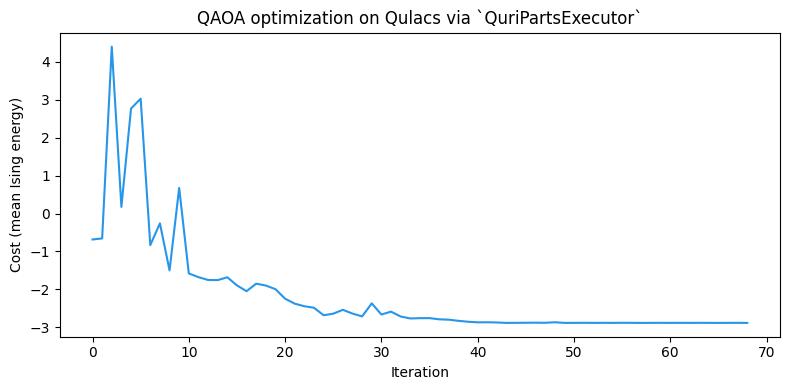

In [10]:
# 最適化の過程における目的関数の変化をプロットします。
plt.figure(figsize=(8, 4))
plt.plot(cost_history, color="#2696EB")
plt.xlabel("Iteration")
plt.ylabel("Cost (mean Ising energy)")
plt.title("QAOA optimization on Qulacs via `QuriPartsExecutor`")
plt.tight_layout()
plt.show()

上の`QuriPartsExecutor`は`seed=42`で構築しているため、Qulacs samplerは再現可能です。このページを再実行しても、同じ最適化の軌跡と最終エネルギーが得られます。非決定的なサンプリングに戻すには、`seed`引数を外してください。
この5ノードグラフでは、$H_C$の基底状態エネルギー付近まで収束するはずです。
ここで得た最適パラメータ(`opt_gammas`、`opt_betas`)を、以降の例でも使います。

## 期待値計算: 未バインド回路とバインド済み回路の違い

`QuriPartsExecutor.estimate_expectation(circuit, hamiltonian, param_values)`は、QURI Partsで期待値を計算するためのメソッドです。
渡された**回路の状態**に応じて、QURI Partsの2種類のestimatorを使い分けます。

- **未バインドのパラメトリック回路**: `transpile()`が生成した直後の回路は、パラメータをまだ自由変数として保持しています。
  QURI Partsの`apply_circuit`はこれを`ParametricCircuitQuantumState`で包み、executorはQURI Partsの**パラメトリックestimator**を呼び出します。
  この場合、評価時に`param_values`の値でパラメータがバインドされます。
- **バインド済みの回路、もしくは最初からパラメータを持たない回路**: 例えば`circuit.bind_parameters([...])`を呼んでパラメータを具体的な数値に固定すると、同じ`apply_circuit`は`GeneralCircuitQuantumState`を返します。
  この場合、executorはQURI Partsの**非パラメトリックestimator**を呼び出し、引数の`param_values`は使われません。

この違いを知っておくと、計算コストを見積もりやすくなります。
同じ回路を異なるパラメータで何度も評価する最適化ループでは、毎回の回路コピーを省けるパラメトリックestimatorが向いています。
逆に、パラメータがすでに具体的な数値に固定されている場合は、パラメトリック回路用の処理が不要な非パラメトリックestimatorのほうが効率的です。

QURI Partsは回路レベルでは`measure`を何もしない命令として扱います。
そのため、`transpiler.transpile(qaoa_ansatz, ...)`が出力するパラメトリック回路は、そのままQAOAの出力状態$|\boldsymbol{\gamma}, \boldsymbol{\beta}\rangle$を準備する回路として使えます。
これをコストハミルトニアンと一緒に`estimate_expectation`に渡せば、サンプリングノイズを含まない$\langle H_C \rangle$を計算できます。
QAOAの最適化でも、同じ回路を保ったまま`executable.sample()`とデコードの組み合わせを`executor.estimate(circuit, hamiltonian, params=...)`に置き換えられます。

2つの経路を直接試すため、まずQamomileの`Hamiltonian`として$H_C = \sum_{(i,j) \in E} Z_i Z_j$を組み立てます。
それをQURI Partsの演算子に変換し、各回路に対して`estimate_expectation`を呼び出します。

In [11]:
# MaxCutのIsingコストに対応するQamomileのHamiltonianを組み立てます。
cost_hamiltonian = qm_o.Hamiltonian()
for (i, j), Jij in spin_model.quad.items():
    cost_hamiltonian.add_term(
        (qm_o.PauliOperator(qm_o.Pauli.Z, i), qm_o.PauliOperator(qm_o.Pauli.Z, j)),
        Jij,
    )
for i, hi in spin_model.linear.items():
    cost_hamiltonian.add_term((qm_o.PauliOperator(qm_o.Pauli.Z, i),), hi)

# 直接期待値計算できるよう、observableをQURI Parts演算子へ変換します。
quri_H = hamiltonian_to_quri_operator(cost_hamiltonian)

# transpiler.transpile()直後の、まだバインドされていないパラメトリック回路
unbound_circuit = executable.get_first_circuit()
assert unbound_circuit is not None
print(f"unbound type           : {type(unbound_circuit).__name__}")
print(f"unbound parameter_count: {unbound_circuit.parameter_count}")

# QURI Partsはランタイムパラメータを「回路に登録された順序のフラットなリスト」
# として要求します。登録順は回路を出力したときの初出順で決まるため、QAOAでは
# gammas[0], betas[0], gammas[1], betas[1], ... と層ごとに交互の順になります。
# 「すべてのgammasのあとにすべてのbetas」という順序ではない点に注意してください。
# 順序を推測しなくて済むよう、executableから登録順を読み取り、
# 名前で値を引いてフラットなリストに整えます。
named_values = {f"gammas[{i}]": opt_gammas[i] for i in range(p)}
named_values.update({f"betas[{i}]": opt_betas[i] for i in range(p)})
flat_params = [named_values[name] for name in executable.parameter_names]
# ランタイムパラメータは2p個のQAOA角度のみです。
assert len(executable.parameter_names) == 2 * p
assert len(flat_params) == 2 * p
print(f"circuit parameter order: {executable.parameter_names}")

# QURI Parts標準のバインド処理で、同じ数値を手動でバインドします。
bound_circuit = unbound_circuit.bind_parameters(flat_params)
print(f"bound   type           : {type(bound_circuit).__name__}")

# 経路1: 未バインド回路 → パラメトリックestimator。param_valuesの値が使われます。
energy_unbound = executor.estimate_expectation(
    unbound_circuit, quri_H, flat_params
)

# 経路2: バインド済み回路 → 非パラメトリックestimator。param_valuesは無視されます。
energy_bound = executor.estimate_expectation(bound_circuit, quri_H, [])

print(f"parametric  estimator: {energy_unbound:+.10f}")
print(f"non-param.  estimator: {energy_bound:+.10f}")
assert np.isclose(energy_unbound, energy_bound, atol=1e-10)

unbound type           : LinearMappedParametricQuantumCircuit
unbound parameter_count: 6
circuit parameter order: ['gammas[0]', 'betas[0]', 'gammas[1]', 'betas[1]', 'gammas[2]', 'betas[2]']
bound   type           : ImmutableBoundParametricQuantumCircuit
parametric  estimator: -2.8538574303
non-param.  estimator: -2.8538574303


両方の経路は数値精度の範囲で一致します。
同じQAOA状態を、同じIsingコストハミルトニアンに対して評価しているためです。
また、最適化後パラメータでのこのノイズなし期待値は、先ほど出力した標本平均エネルギーともショットノイズの範囲で一致するはずです。
この経路の切り替えはQamomileの`executor.estimate()`インターフェース内部に隠れているので、通常は意識する必要はありません。
`estimate_expectation`を直接呼び出すのは、QURI Partsの回路を自分で扱う場合に限られます。

`executor.estimate(circuit, hamiltonian, params=...)`は、Qamomileのオブジェクトをそのまま扱える、より使いやすいメソッドです。
`qamomile.observable.Hamiltonian`を直接受け取り、内部で自動変換してから`estimate_expectation`を呼び出します。

In [12]:
# QamomileのHamiltonianをそのまま受け取れるestimatorを使います。
energy_via_estimate = executor.estimate(
    unbound_circuit, cost_hamiltonian, params=flat_params
)
print(f"executor.estimate     : {energy_via_estimate:+.10f}")
assert np.isclose(energy_via_estimate, energy_unbound, atol=1e-10)

executor.estimate     : -2.8538574303


## 他のQURI Partsバックエンドの利用

`QuriPartsExecutor()`は、初回利用時にデフォルトのQulacs状態ベクトルsamplerとパラメトリックestimatorを遅延生成します。
別のQURI Partsバックエンドに差し替えたい場合は、`QuriPartsTranspiler.executor(sampler=..., estimator=...)`経由でsamplerやestimatorを渡すか、`QuriPartsExecutor(sampler=..., estimator=...)`を直接インスタンス化します。
差し替えたexecutorは、上で使った`executor`の位置にそのまま当てはめられます。
samplerを変えても、量子カーネルをトランスパイルし直す必要はありません。
`executable`が回路を持ち、`executor`が実行に使うsamplerやestimatorを持つ、という役割分担になっているためです。

具体例として、QURI PartsのQulacs用`NoiseSimulator`を使ったノイズ込みsamplerを構築します。
そして、**同じ**最適化済みパラメータに対して、ノイズなし版とノイズあり版の標本平均エネルギーを比較します。
すべてのゲートに脱分極ノイズがかかれば、ノイズあり側の平均エネルギーはノイズなしの値からずれるはずです。
これにより、差し替えたsamplerが実際に使われていることを確認できます。

In [13]:
# Qulacsのnoise-simulator samplerを作り、Executorへ渡します。
noise_model = NoiseModel([DepolarizingNoise(error_prob=0.02)])
noisy_sampler = create_qulacs_noisesimulator_sampler(noise_model)
noisy_executor = transpiler.executor(sampler=noisy_sampler)

# 同じexecutableを、ノイズなしsamplerとノイズありsamplerで実行します。
clean_result = executable.sample(
    executor,
    bindings={"gammas": opt_gammas, "betas": opt_betas},
    shots=sample_shots,
).result()
noisy_result = executable.sample(
    noisy_executor,
    bindings={"gammas": opt_gammas, "betas": opt_betas},
    shots=sample_shots,
).result()

# 両方のサンプル集合をデコードし、平均Isingエネルギーを比較します。
clean_energy = spin_model.decode_from_sampleresult(clean_result).energy_mean()
noisy_energy = spin_model.decode_from_sampleresult(noisy_result).energy_mean()
print(f"noiseless sampler mean energy: {clean_energy:+.4f}")
print(f"noisy     sampler mean energy: {noisy_energy:+.4f}")

noiseless sampler mean energy: -2.8810
noisy     sampler mean energy: -1.6260


脱分極ノイズはQAOA状態を最大混合状態へ近づけます。
その極限ではすべてのスピン配置が等確率になり、$H_C$の平均値は$0$に収束します。
そのため、ノイズあり側の平均エネルギーは、ノイズなしよりも$0$に近い、つまり高い値になります。
`error_prob`を大きくしたり、ノイズチャネルを追加したりすれば、ノイズあり側のエネルギーはさらに$0$へ近づきます。
逆に`error_prob=0.0`にすれば、ショットノイズの範囲でノイズなしの値に戻ります。
リモートデバイス、密度行列シミュレータ、確率的な状態ベクトルsamplerなど、他のQURI Parts samplerに差し替える場合も同じやり方で動作します。
どの場合でも、量子カーネルの再トランスパイルは不要です。

## まとめ

- `QuriPartsTranspiler().transpile(kernel, bindings=..., parameters=[...])`は量子カーネルをQURI Partsの`LinearMappedParametricQuantumCircuit`に変換し、QURI Partsの`draw_circuit`でそのまま確認できます。
- `QuriPartsExecutor`は、デフォルトのQulacs状態ベクトルシミュレータ上で、QAOA形式のサンプリングを行う`executable.sample()`と、ノイズなしの期待値計算を行う`executor.estimate(...)`の両方をサポートします。
- `estimate_expectation`は、渡された回路にフリーパラメータが残っているかどうかに応じて、QURI Partsのパラメトリックestimatorと非パラメトリックestimatorを切り替えます。通常は`executor.estimate()`を使えば、この切り替えを意識せずに済みます。
- QURI Partsの`NoiseSimulator`ベースのsamplerなど、独自のsamplerやestimatorは`transpiler.executor(...)`経由で差し替えられます。量子カーネルをトランスパイルし直す必要はありません。